# Анализ режимов бурения: KMeans k=5–9

Визуализация кластеров, распределений и поверхностей отклика.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as mplcm
import lightgbm as lgb
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 21
K_RANGE = range(5, 10)
CLUSTER_FEATURES = ['pressure_axis', 'pressure_rotation', 'speed', 'rotation']
GRID_RES = 60

df = pd.read_feather('../datasets/united.feather')
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[CLUSTER_FEATURES])

all_labels = {}
for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    all_labels[k] = km.fit_predict(X_scaled)
    df[f'cluster_k{k}'] = all_labels[k]

colors_mpl = mplcm.tab10.colors
print(f'Data: {df.shape[0]:,} rows')

Data: 415,049 rows


## 1. Количество наблюдений в каждом кластере

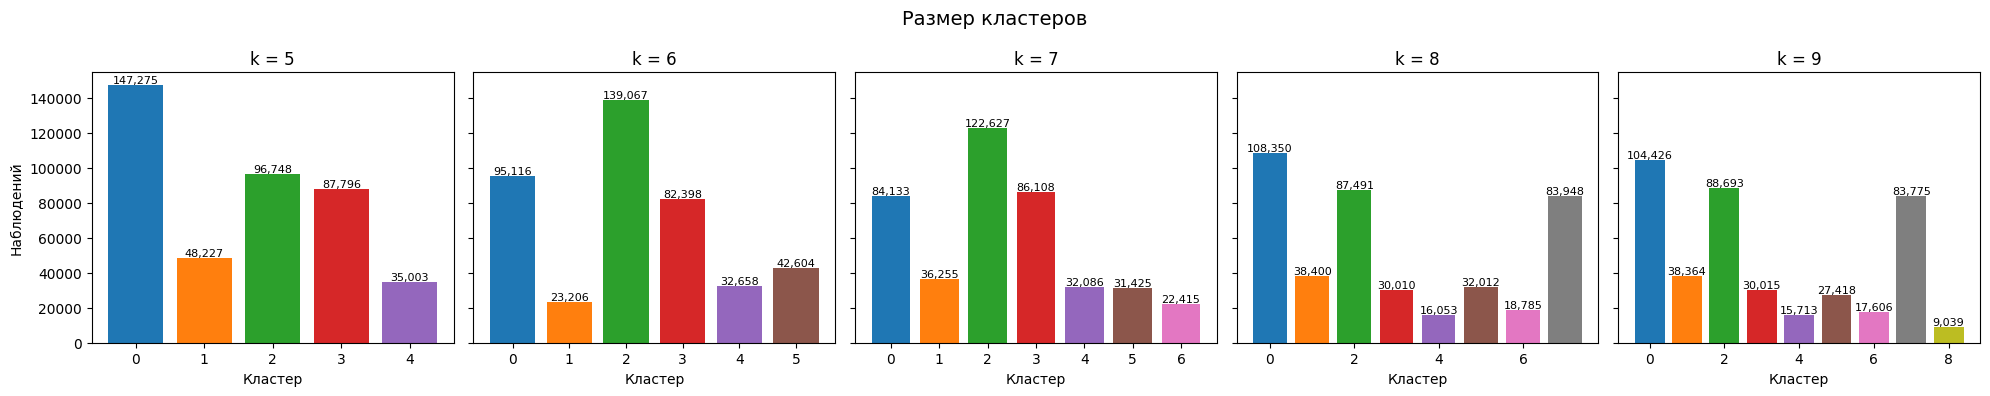

In [4]:
fig, axes = plt.subplots(1, len(K_RANGE), figsize=(4 * len(K_RANGE), 4), sharey=True)

for ax, k in zip(axes, K_RANGE):
    col = f'cluster_k{k}'
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values,
                  color=[colors_mpl[i % 10] for i in counts.index])
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v,
                f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'k = {k}')
    ax.set_xlabel('Кластер')
    if k == K_RANGE[0]:
        ax.set_ylabel('Наблюдений')

plt.suptitle('Размер кластеров', fontsize=14)
plt.tight_layout()
plt.show()

## 2. Boxplot — распределение speed и rotation по кластерам

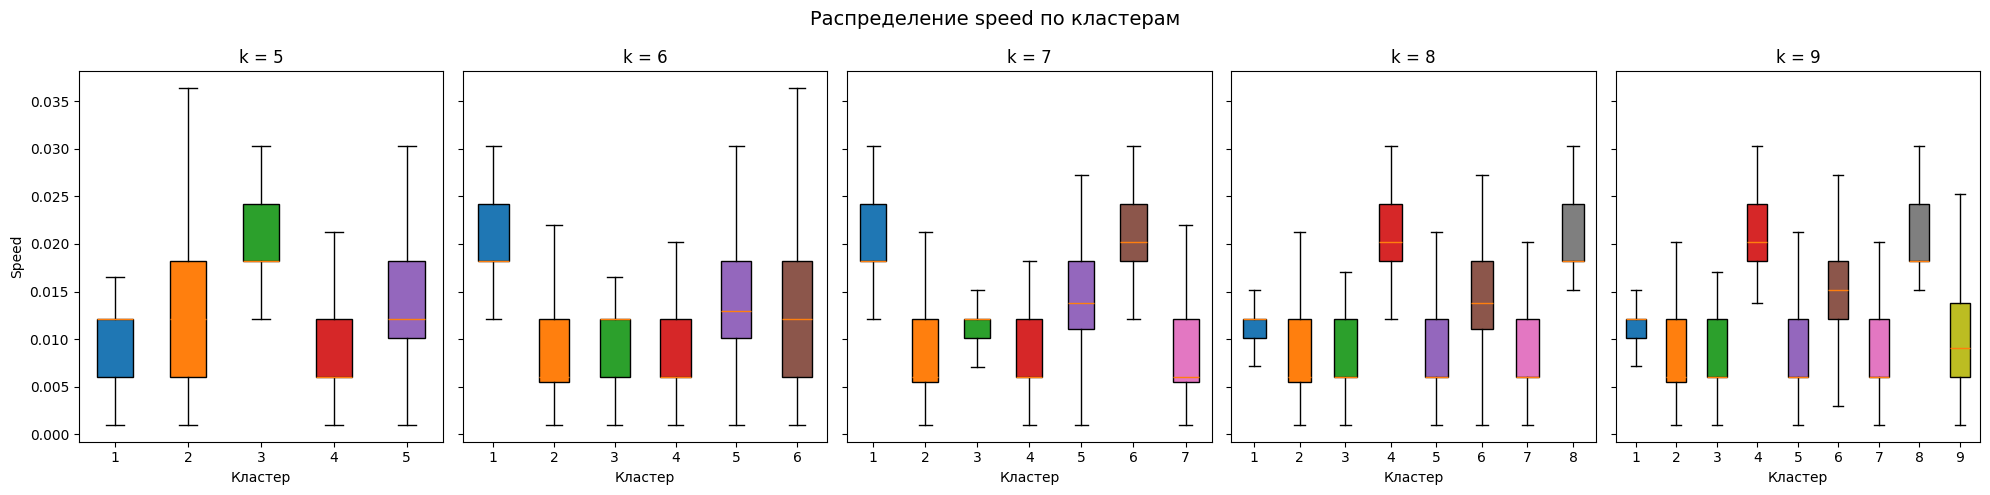

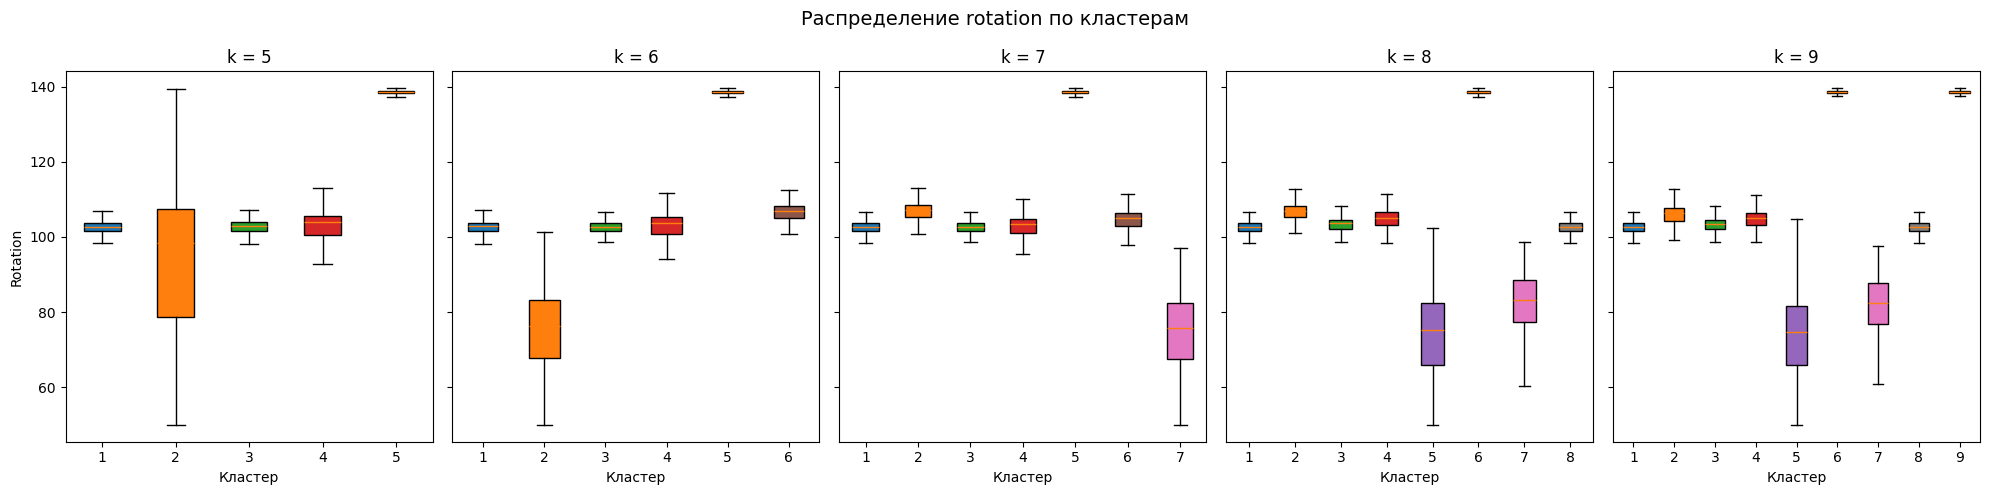

In [5]:
for target, ylabel in [('speed', 'Speed'), ('rotation', 'Rotation')]:
    fig, axes = plt.subplots(1, len(K_RANGE), figsize=(4 * len(K_RANGE), 5), sharey=True)
    for ax, k in zip(axes, K_RANGE):
        col = f'cluster_k{k}'
        data_bp = [df.loc[df[col] == c, target].values for c in sorted(df[col].unique())]
        bp = ax.boxplot(data_bp, patch_artist=True, showfliers=False)
        for patch, c in zip(bp['boxes'], range(k)):
            patch.set_facecolor(colors_mpl[c % 10])
        ax.set_title(f'k = {k}')
        ax.set_xlabel('Кластер')
        if k == K_RANGE[0]:
            ax.set_ylabel(ylabel)
    plt.suptitle(f'Распределение {target} по кластерам', fontsize=14)
    plt.tight_layout()
    plt.show()

## 3. Вспомогательные функции

In [6]:
def fit_cluster_models(labels, target):
    models = {}
    for cid in sorted(np.unique(labels)):
        mask = labels == cid
        X = df.loc[mask, ['pressure_axis', 'pressure_rotation']]
        y = df.loc[mask, target]
        m = lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
                              n_estimators=200, max_depth=6)
        m.fit(X, y)
        models[cid] = m
    return models


def make_grid(sub, res=GRID_RES):
    pa_lo, pa_hi = sub['pressure_axis'].quantile(0.05), sub['pressure_axis'].quantile(0.95)
    pr_lo, pr_hi = sub['pressure_rotation'].quantile(0.05), sub['pressure_rotation'].quantile(0.95)
    PA, PR = np.meshgrid(np.linspace(pa_lo, pa_hi, res), np.linspace(pr_lo, pr_hi, res))
    return PA, PR


def predict_grid(model, PA, PR):
    grid_flat = np.column_stack([PA.ravel(), PR.ravel()])
    V = model.predict(grid_flat).reshape(PA.shape)
    return V, grid_flat

## 4. Contourf — поверхность отклика speed (вид сверху)

○ среднее по кластеру, ★ оптимум на сетке

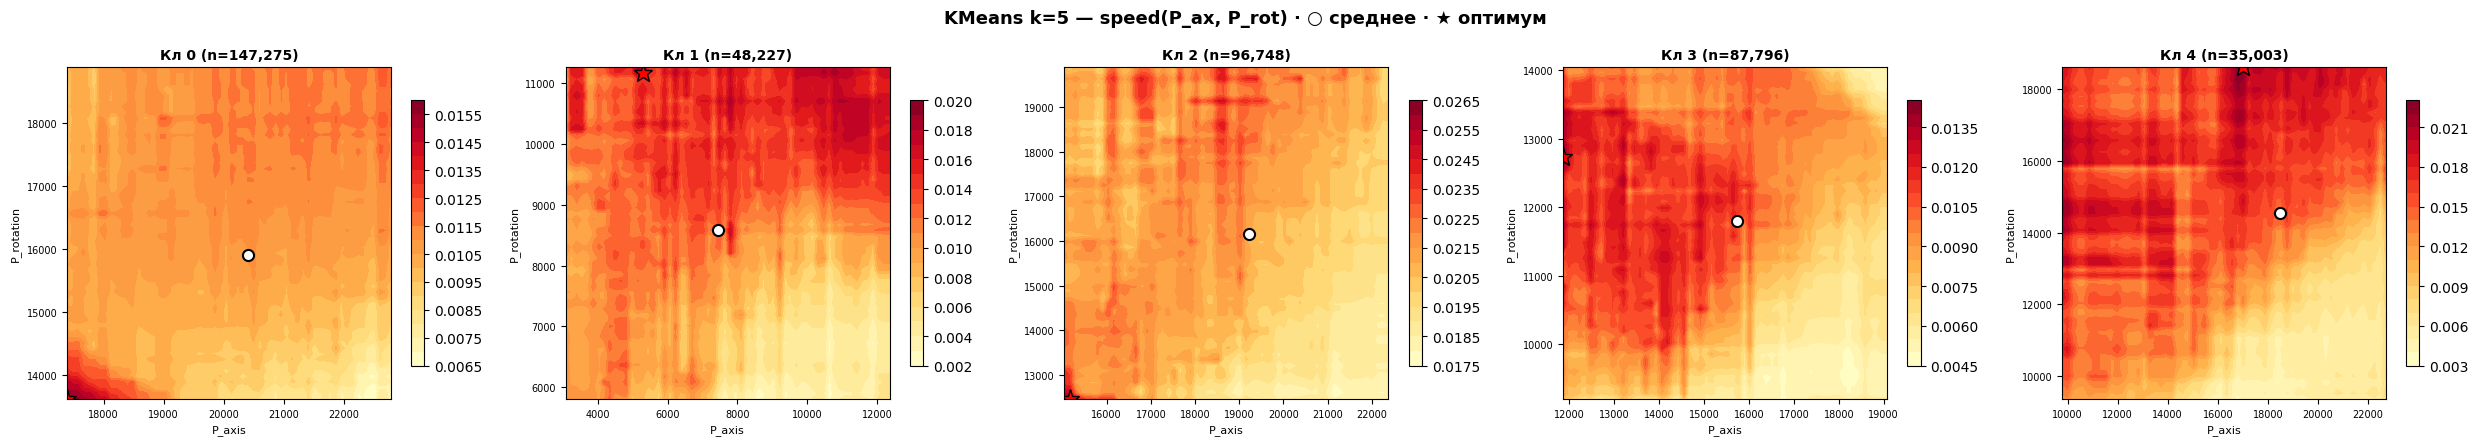

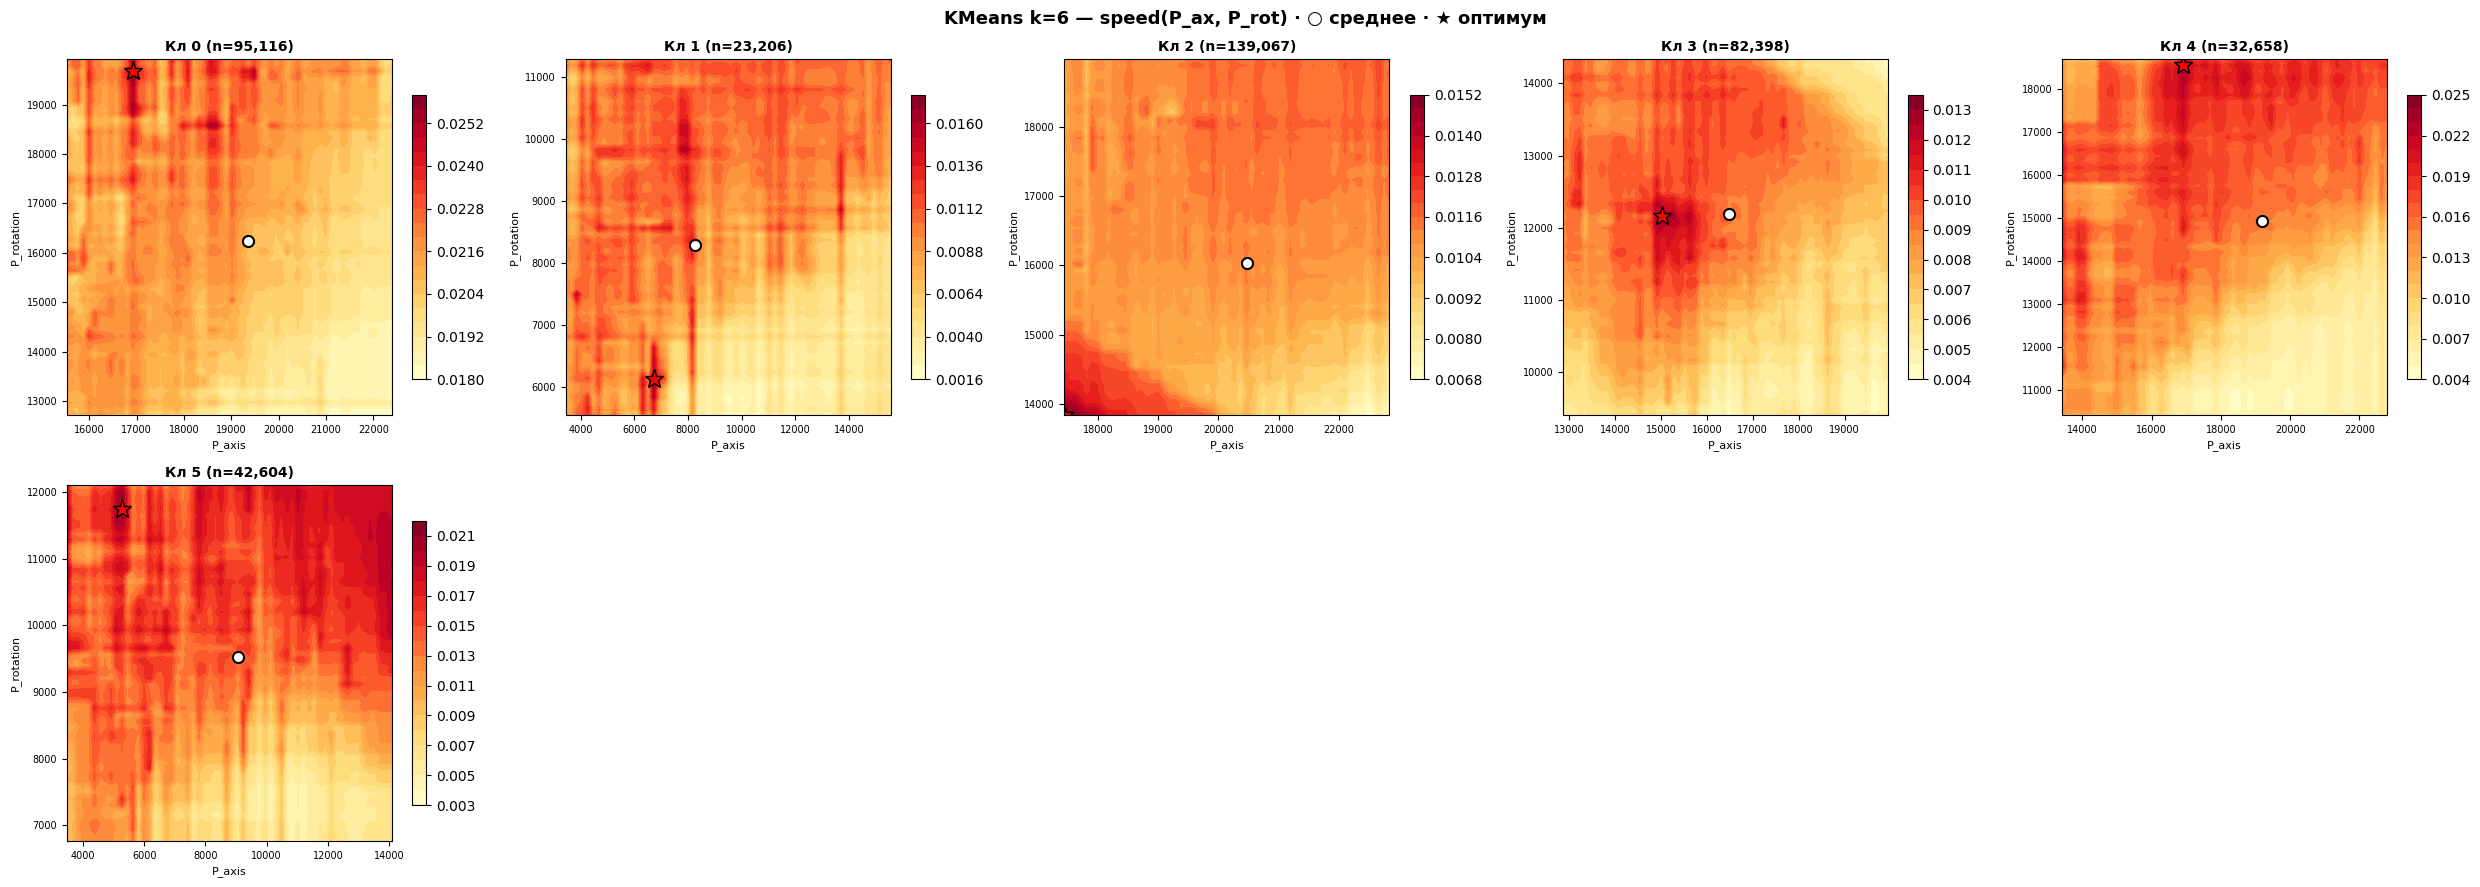

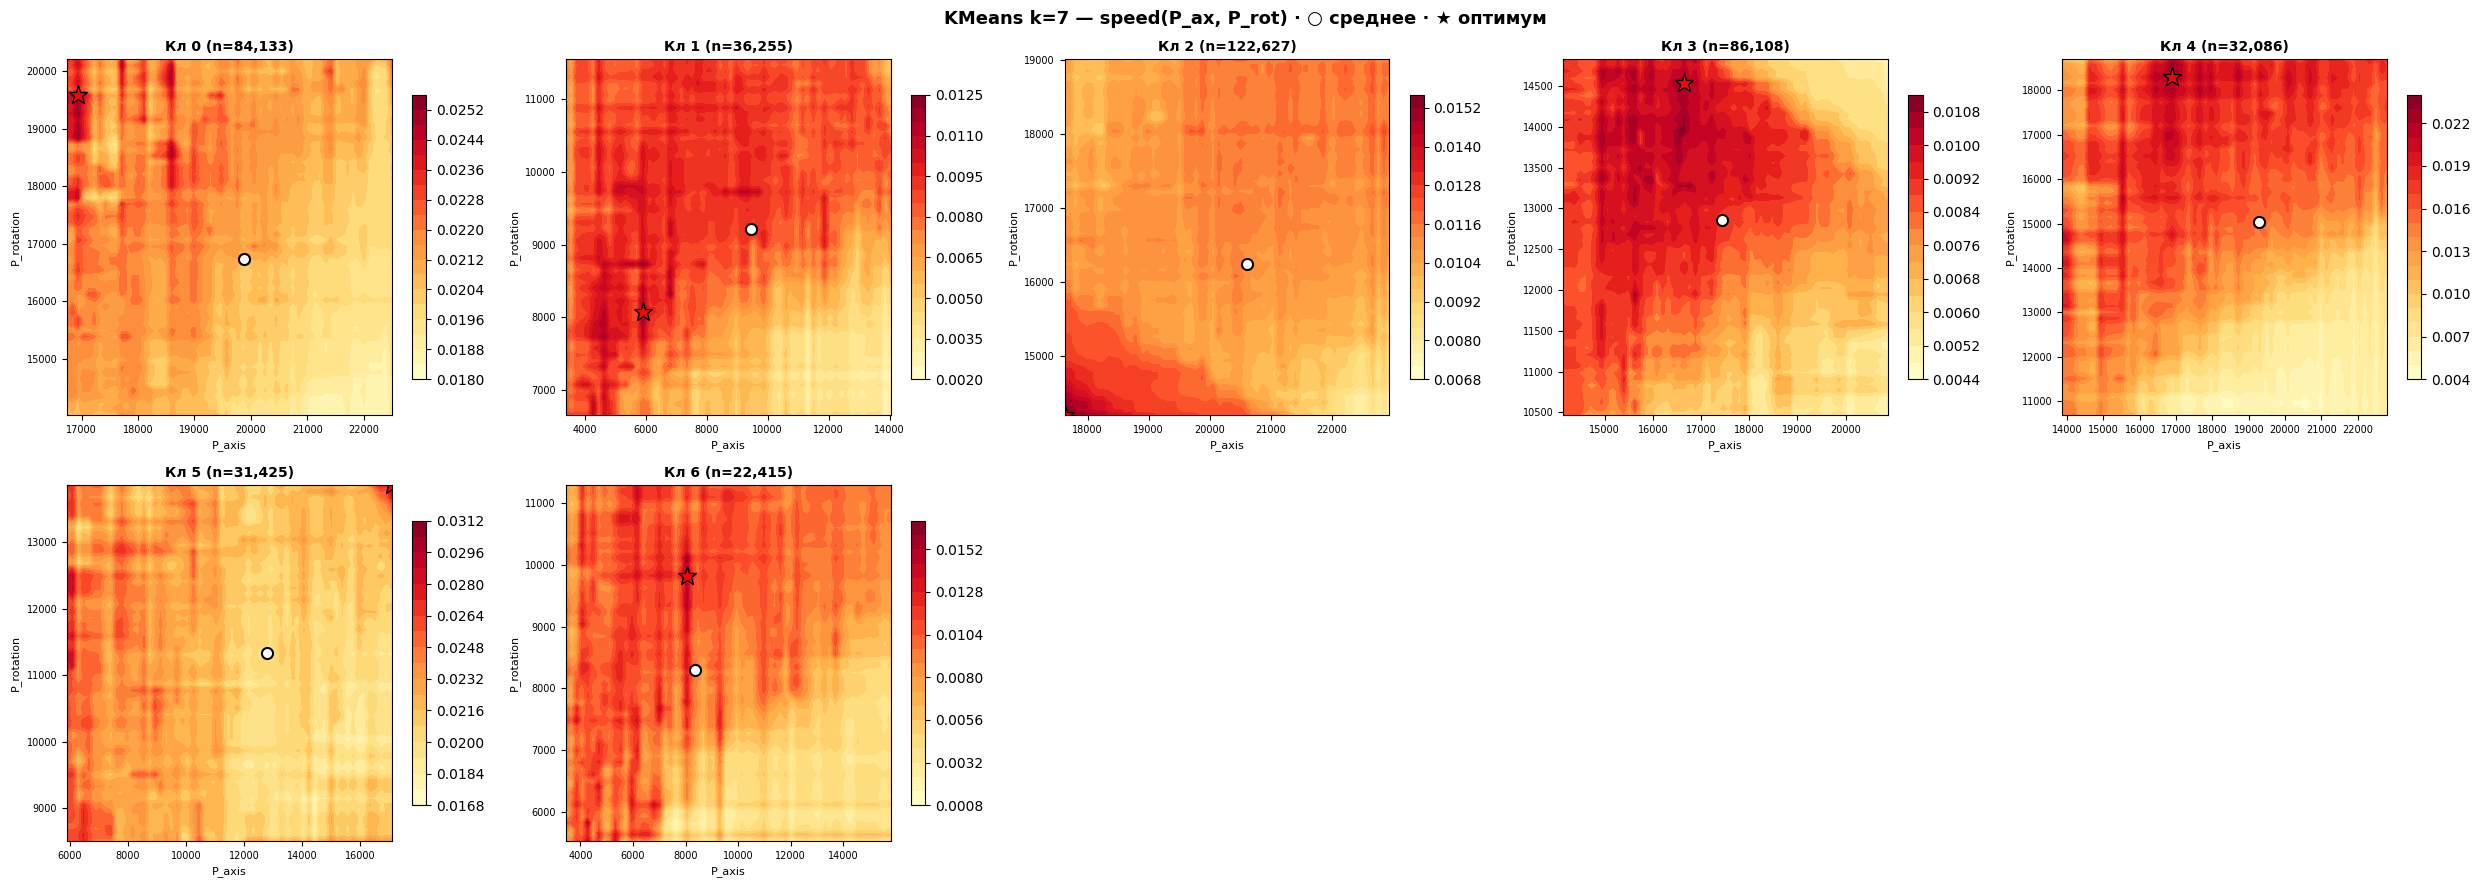

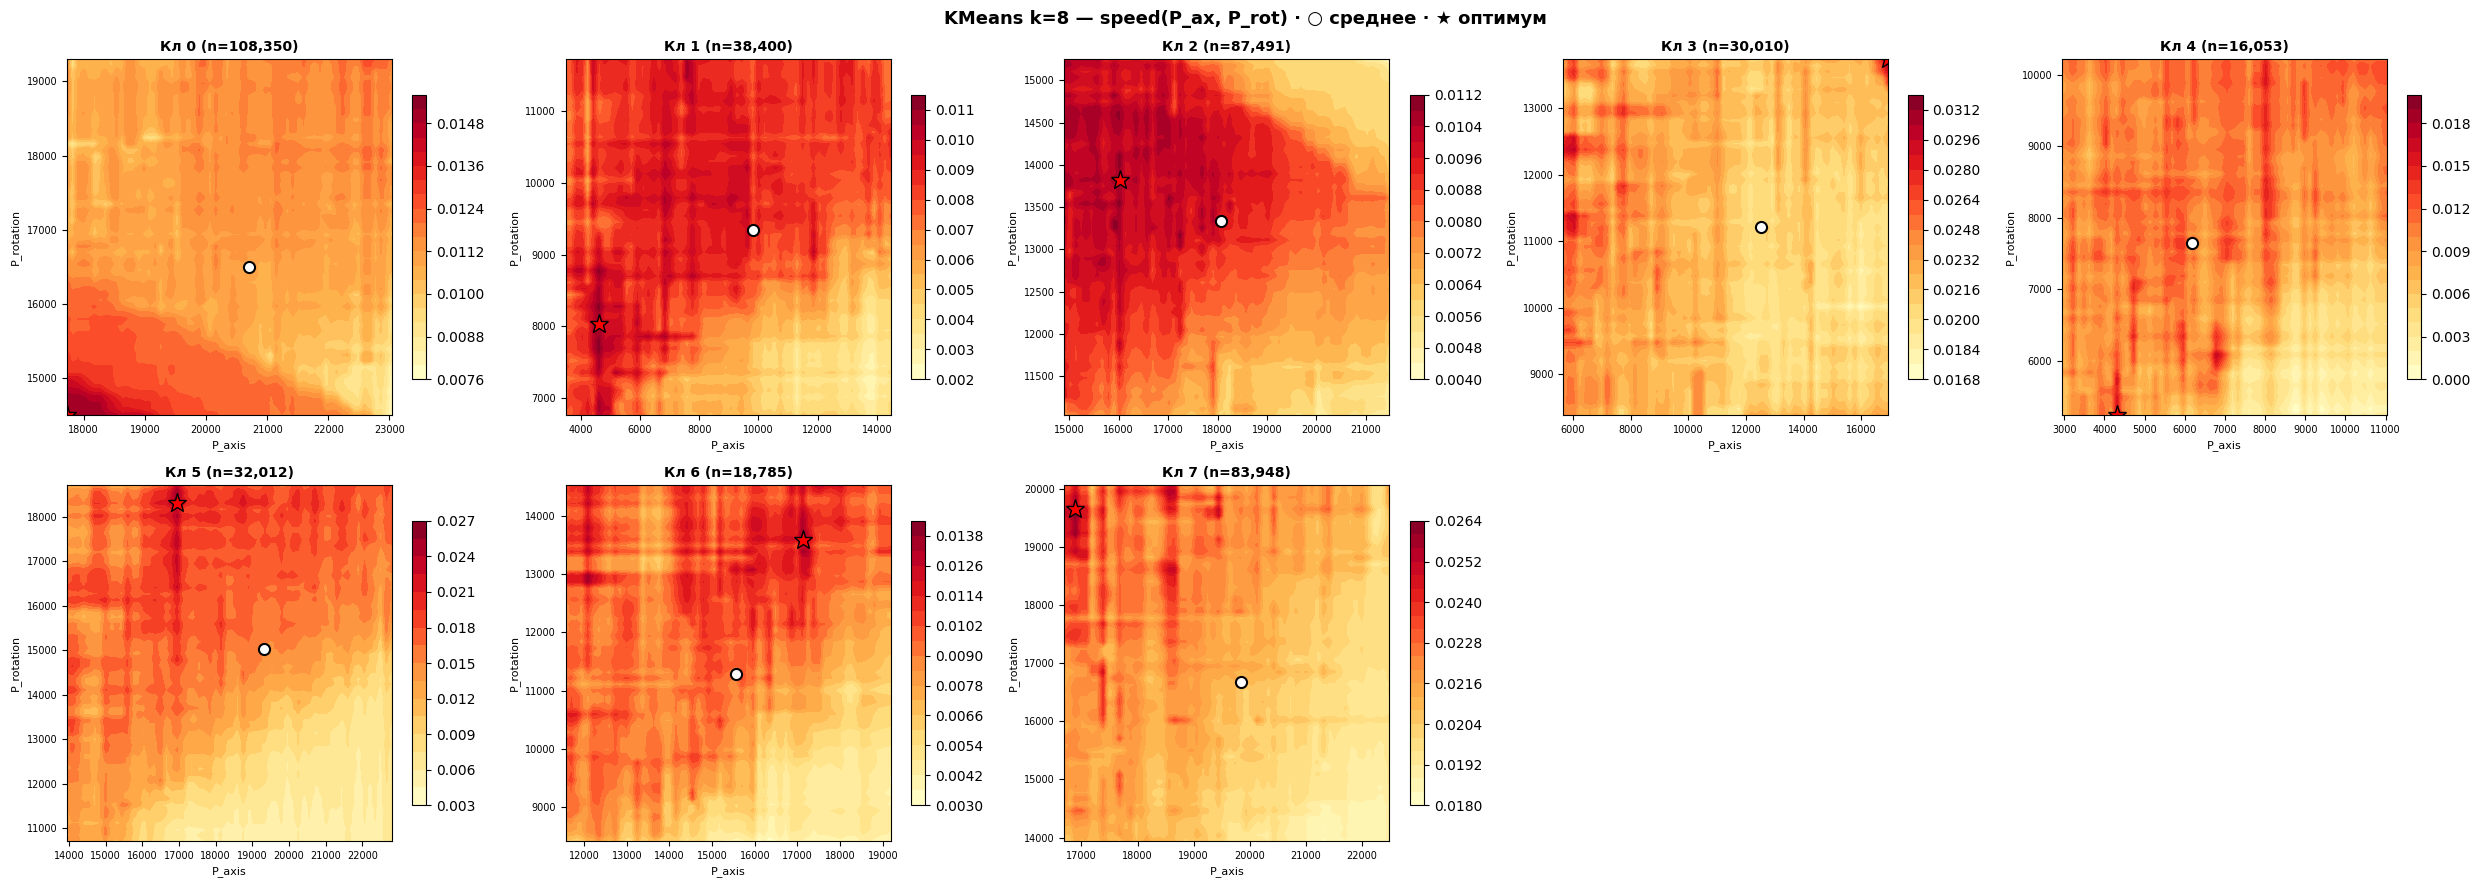

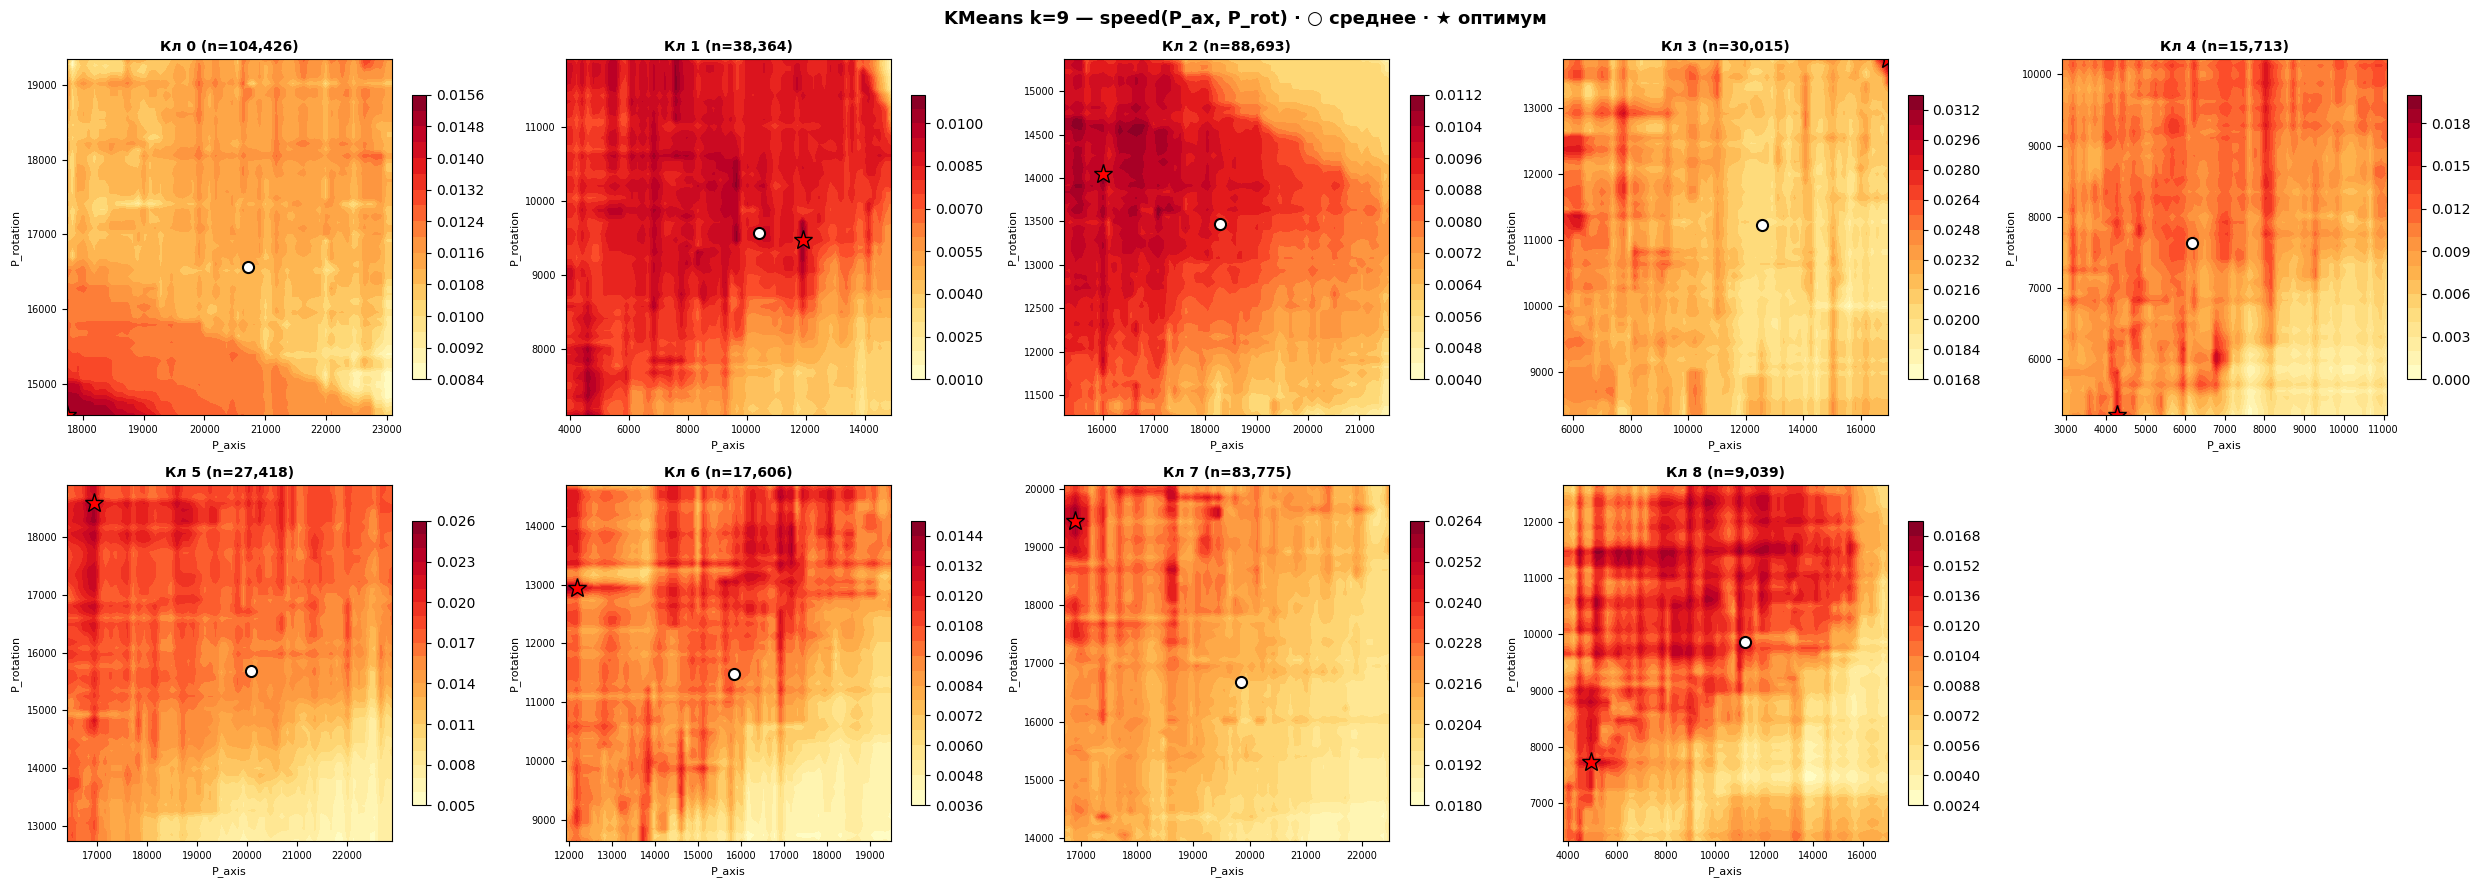

In [7]:
for k in K_RANGE:
    labels = all_labels[k]
    models_speed = fit_cluster_models(labels, 'speed')
    
    ncols = min(k, 5)
    nrows = (k + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_2d(axes)
    
    for cid in range(k):
        ax = axes[cid // ncols, cid % ncols]
        sub = df[labels == cid]
        PA, PR = make_grid(sub)
        V, grid_flat = predict_grid(models_speed[cid], PA, PR)
        
        cf = ax.contourf(PA, PR, V, levels=20, cmap='YlOrRd')
        plt.colorbar(cf, ax=ax, shrink=0.8)
        
        ax.plot(sub['pressure_axis'].mean(), sub['pressure_rotation'].mean(),
                'wo', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
        
        v_flat = models_speed[cid].predict(grid_flat)
        best_idx = np.argmax(v_flat)
        ax.plot(grid_flat[best_idx, 0], grid_flat[best_idx, 1],
                'r*', markersize=14, markeredgecolor='black')
        
        ax.set_title(f'Кл {cid} (n={len(sub):,})', fontsize=10, fontweight='bold')
        ax.set_xlabel('P_axis', fontsize=8)
        ax.set_ylabel('P_rotation', fontsize=8)
        ax.tick_params(labelsize=7)
    
    for idx in range(k, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)
    
    plt.suptitle(f'KMeans k={k} — speed(P_ax, P_rot) · ○ среднее · ★ оптимум',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## 5. Contourf — поверхность отклика rotation (вид сверху)

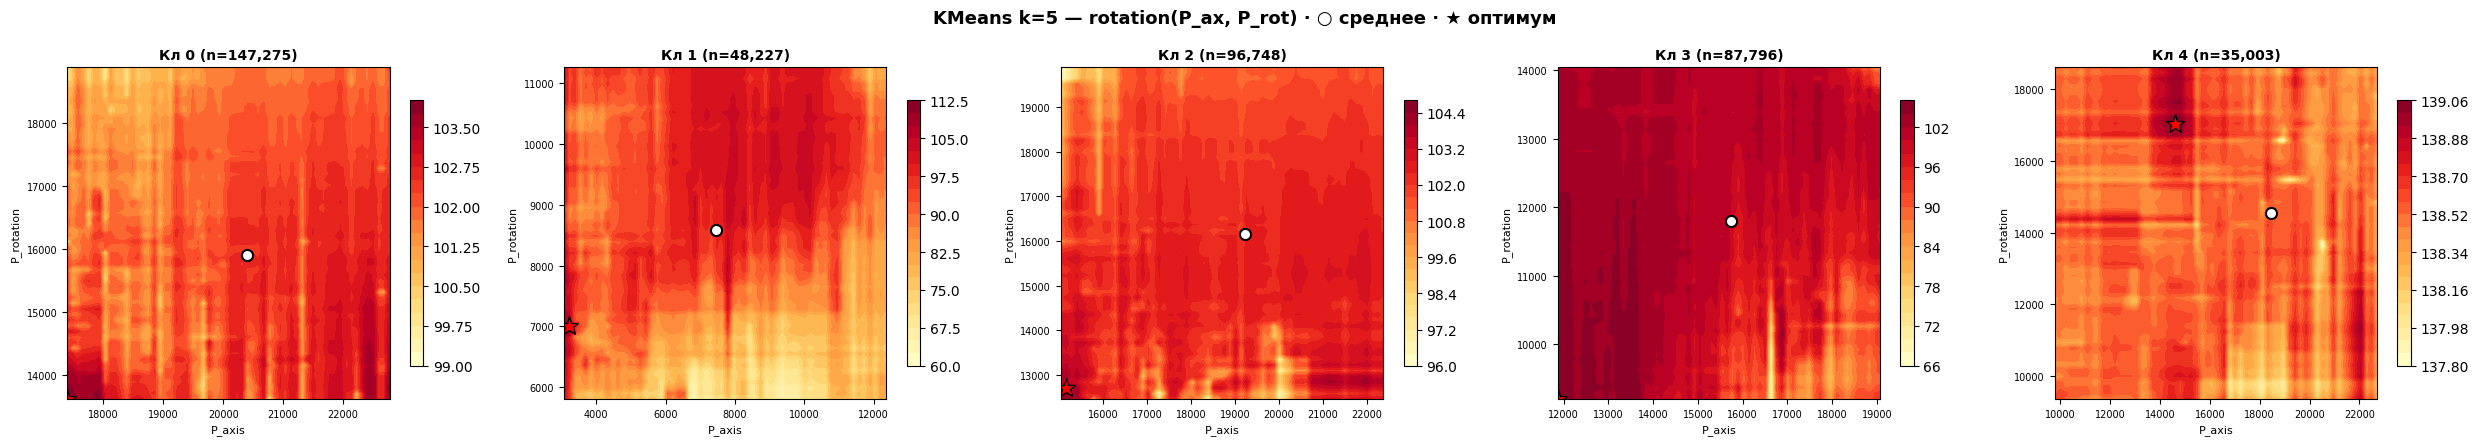

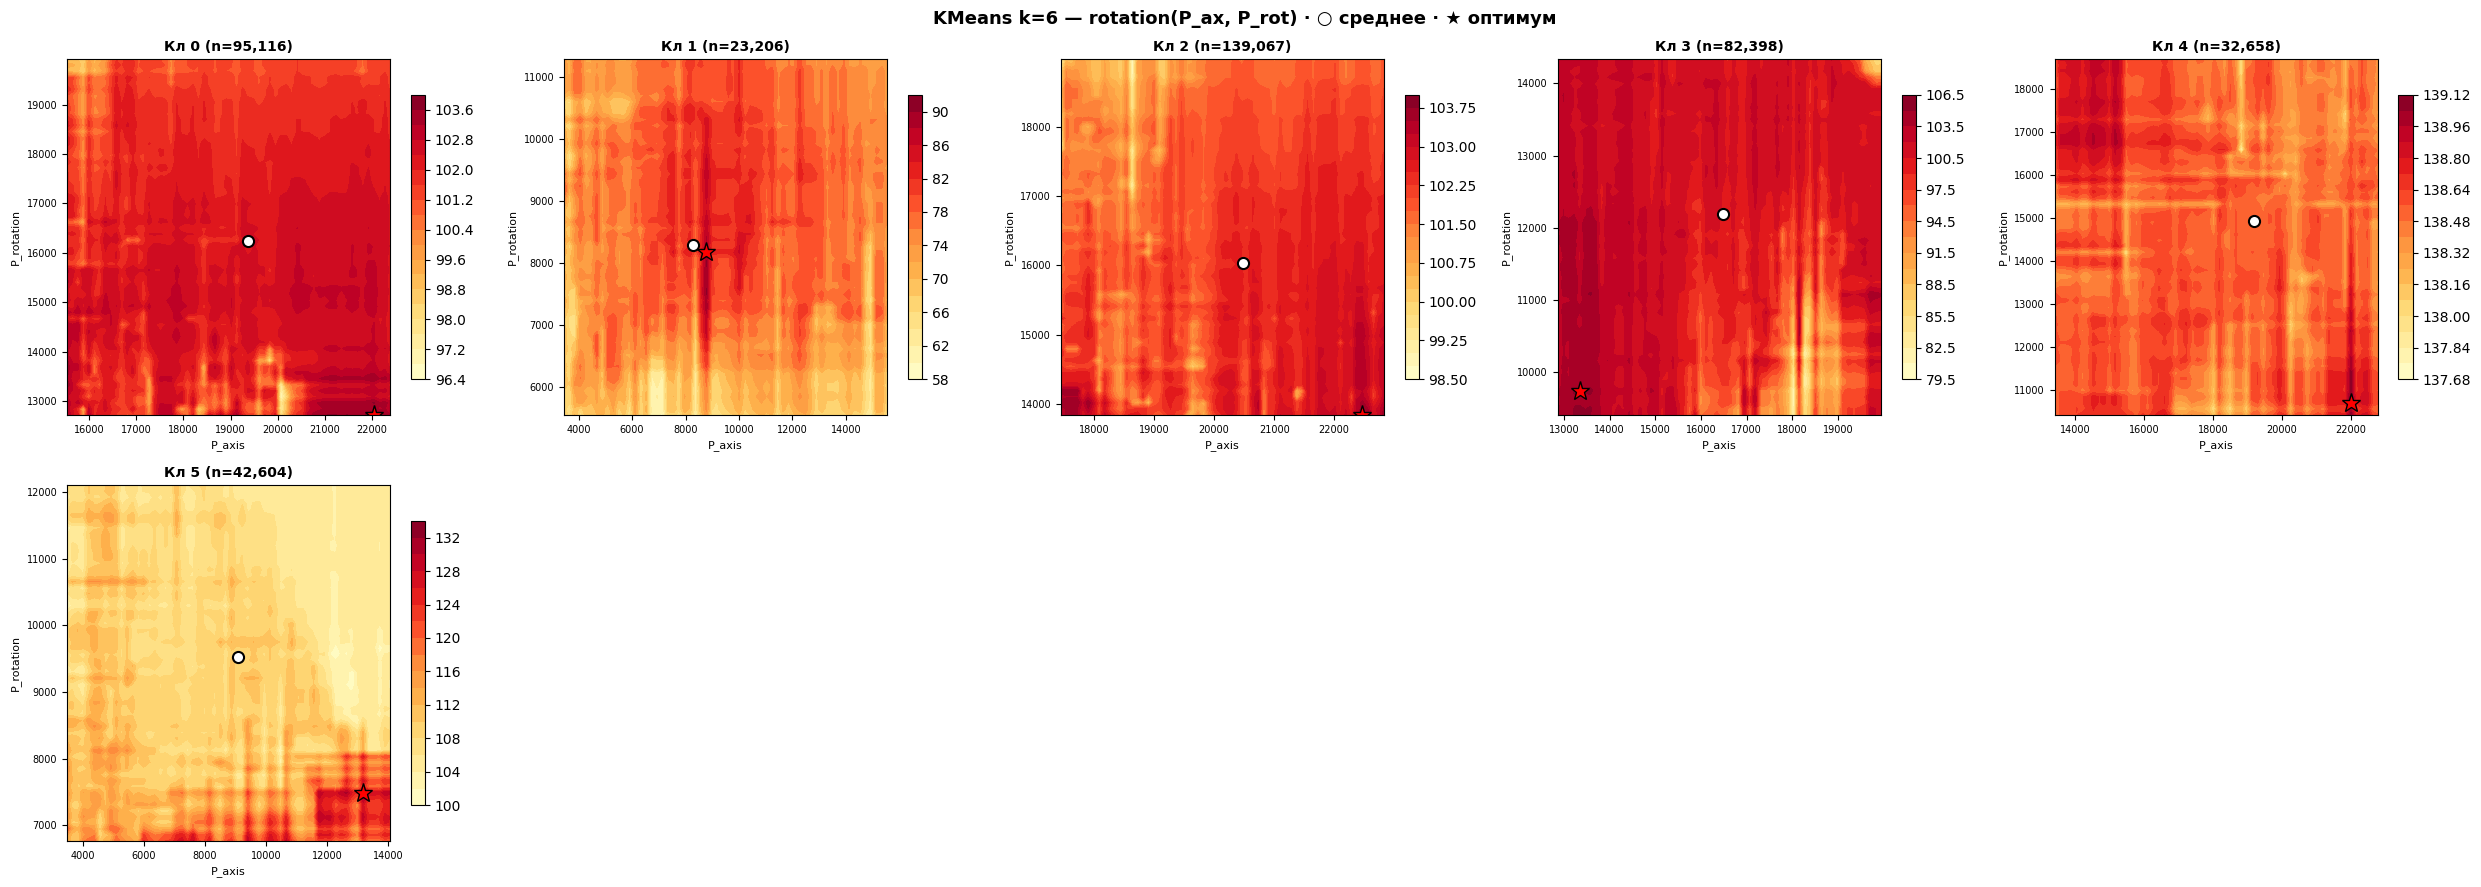

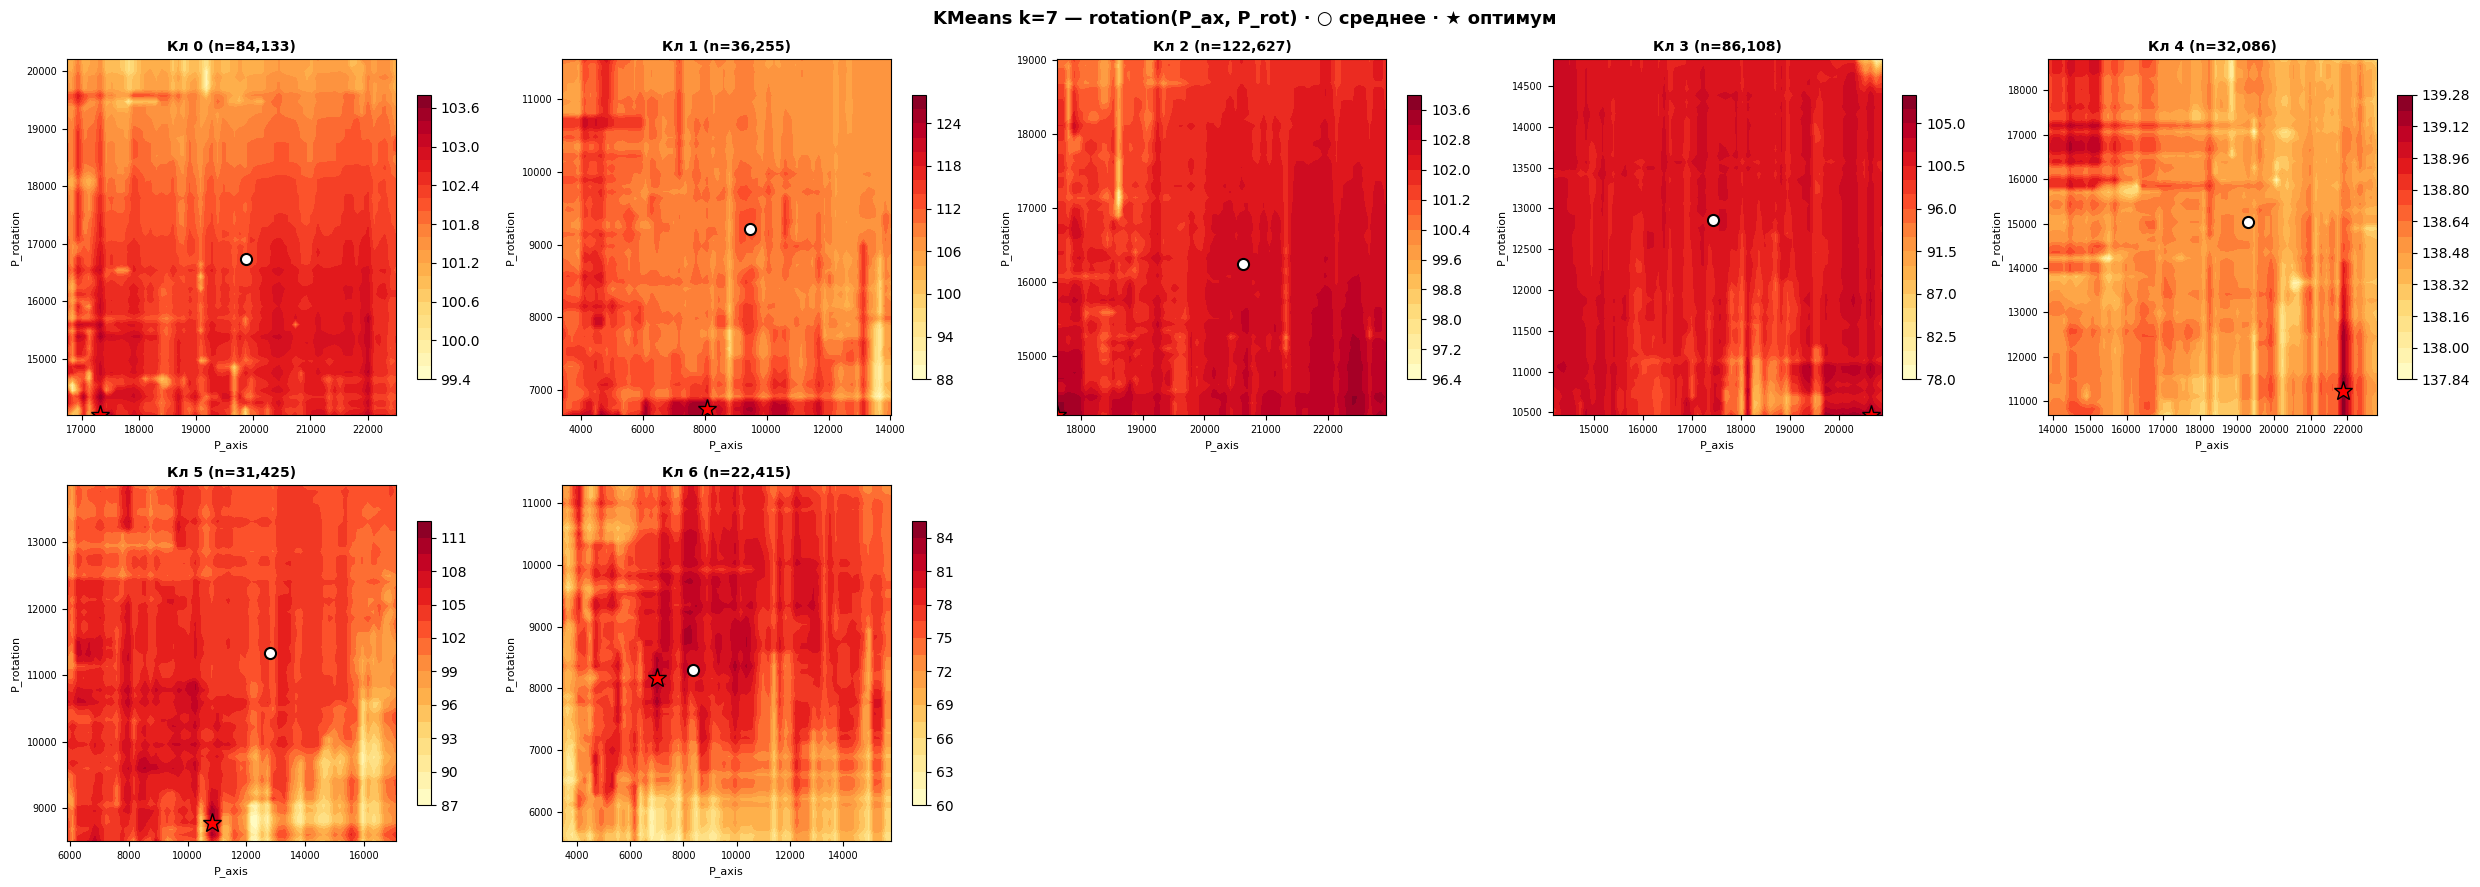

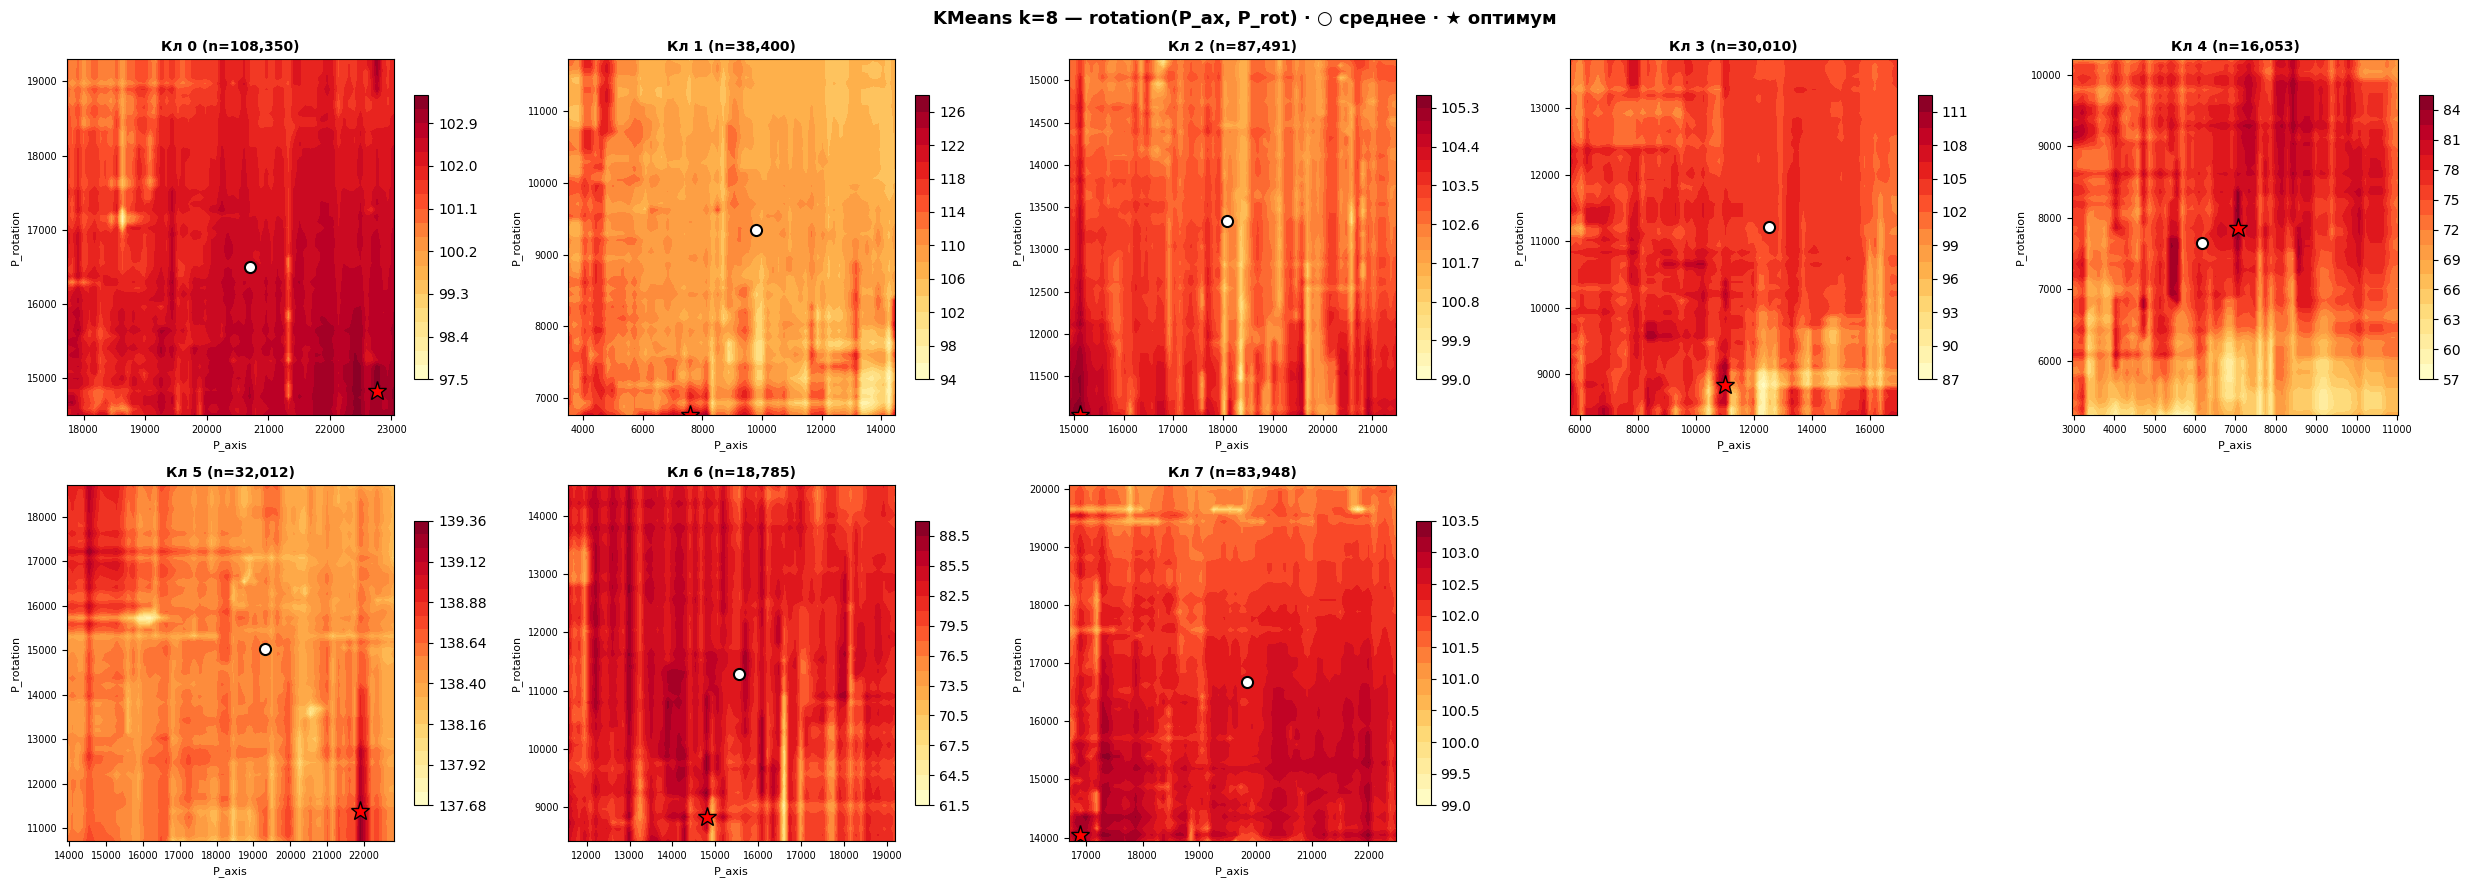

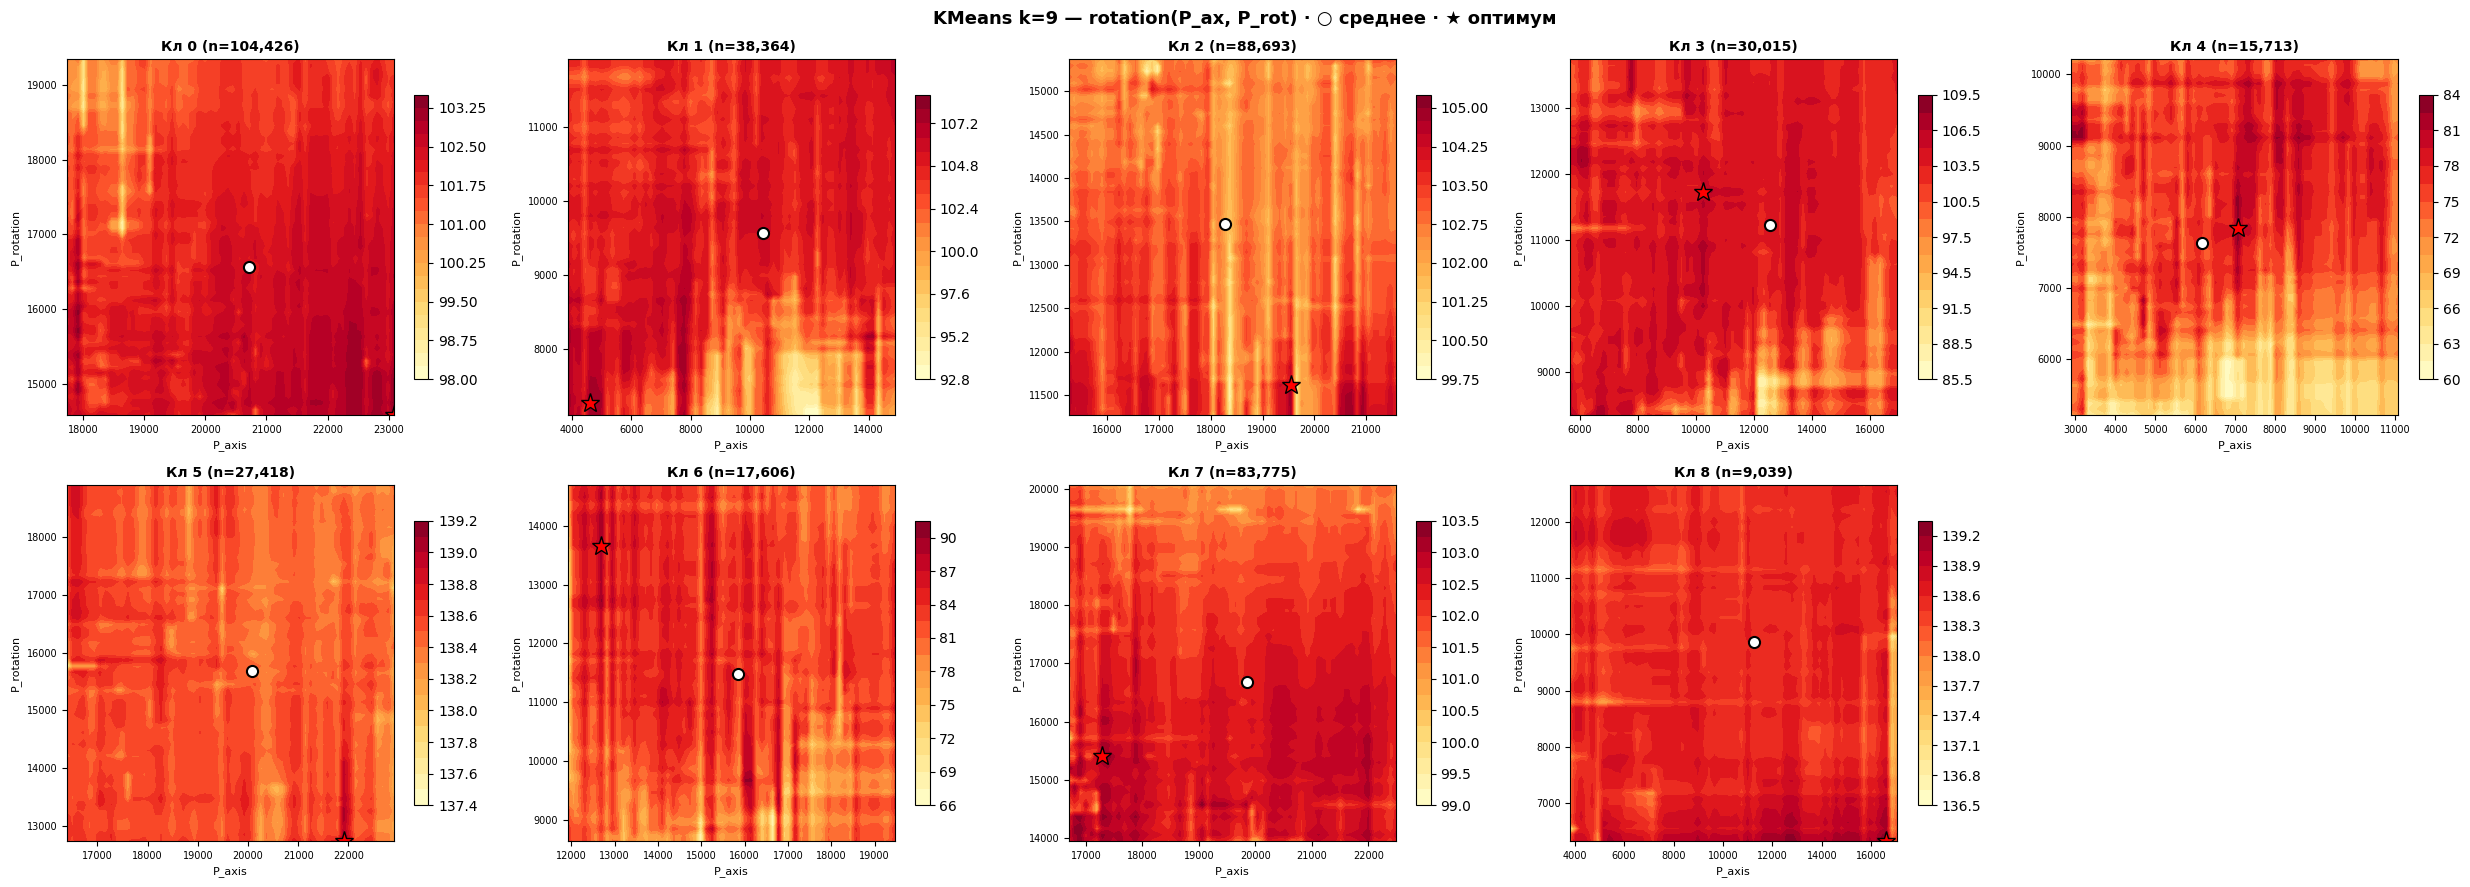

In [8]:
for k in K_RANGE:
    labels = all_labels[k]
    models_rot = fit_cluster_models(labels, 'rotation')
    
    ncols = min(k, 5)
    nrows = (k + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
    axes = np.atleast_2d(axes)
    
    for cid in range(k):
        ax = axes[cid // ncols, cid % ncols]
        sub = df[labels == cid]
        PA, PR = make_grid(sub)
        V, grid_flat = predict_grid(models_rot[cid], PA, PR)
        
        cf = ax.contourf(PA, PR, V, levels=20, cmap='YlOrRd')
        plt.colorbar(cf, ax=ax, shrink=0.8)
        
        ax.plot(sub['pressure_axis'].mean(), sub['pressure_rotation'].mean(),
                'wo', markersize=8, markeredgecolor='black', markeredgewidth=1.5)
        
        v_flat = models_rot[cid].predict(grid_flat)
        best_idx = np.argmax(v_flat)
        ax.plot(grid_flat[best_idx, 0], grid_flat[best_idx, 1],
                'r*', markersize=14, markeredgecolor='black')
        
        ax.set_title(f'Кл {cid} (n={len(sub):,})', fontsize=10, fontweight='bold')
        ax.set_xlabel('P_axis', fontsize=8)
        ax.set_ylabel('P_rotation', fontsize=8)
        ax.tick_params(labelsize=7)
    
    for idx in range(k, nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)
    
    plt.suptitle(f'KMeans k={k} — rotation(P_ax, P_rot) · ○ среднее · ★ оптимум',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

# 6 plotly speed+rotation

In [ ]:

for k in K_RANGE:
    labels = all_labels[k]
    models_speed = fit_cluster_models(labels, 'speed')
    models_rot   = fit_cluster_models(labels, 'rotation')

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "scene"}, {"type": "scene"}]],
        subplot_titles=[
            f'speed(P_ax, P_rot)  k={k}',
            f'rotation(P_ax, P_rot)  k={k}',
        ],
    )

    for cid in range(k):
        sub = df[labels == cid]
        cscale = SURFACE_COLORSCALES[cid % len(SURFACE_COLORSCALES)]
        lg = f'cluster_{cid}'

        # ── Speed (scene1, col=1) ──
        PA, PR = make_grid(sub, res=25)
        V_s, gf_s = predict_grid(models_speed[cid], PA, PR)

        fig.add_trace(go.Surface(
            x=PA, y=PR, z=V_s,
            colorscale=cscale, showscale=False, opacity=0.85,
            name=f'Кластер {cid}',
            legendgroup=lg, showlegend=True,
            scene='scene',          # ← привязка к левой сцене
        ), row=1, col=1)

        v_flat = models_speed[cid].predict(gf_s)
        bi = np.argmax(v_flat)
        fig.add_trace(go.Scatter3d(
            x=[gf_s[bi, 0]], y=[gf_s[bi, 1]], z=[v_flat[bi]],
            mode='markers+text',
            marker=dict(size=7, color='red', symbol='diamond',
                        line=dict(width=2, color='black')),
            text=[f'c{cid}: {v_flat[bi]:.4f}'],
            textposition='top center',
            legendgroup=lg, showlegend=False,
            scene='scene',
        ), row=1, col=1)

        # ── Rotation (scene2, col=2) ──
        PA2, PR2 = make_grid(sub, res=40)
        V_r, gf_r = predict_grid(models_rot[cid], PA2, PR2)

        fig.add_trace(go.Surface(
            x=PA2, y=PR2, z=V_r,
            colorscale=cscale, showscale=False, opacity=0.85,
            name=f'Кластер {cid}',
            legendgroup=lg, showlegend=False,   # уже есть в легенде
            scene='scene2',
        ), row=1, col=2)

        v_flat2 = models_rot[cid].predict(gf_r)
        bi2 = np.argmax(v_flat2)
        fig.add_trace(go.Scatter3d(
            x=[gf_r[bi2, 0]], y=[gf_r[bi2, 1]], z=[v_flat2[bi2]],
            mode='markers+text',
            marker=dict(size=7, color='red', symbol='diamond',
                        line=dict(width=2, color='black')),
            text=[f'c{cid}: {v_flat2[bi2]:.1f}'],
            textposition='top center',
            legendgroup=lg, showlegend=False,
            scene='scene2',
        ), row=1, col=2)

    fig.update_layout(
        title=f'KMeans k={k} — Speed & Rotation',
        scene=dict(
            xaxis_title='P_axis',
            yaxis_title='P_rotation',
            zaxis_title='Speed',
        ),
        scene2=dict(
            xaxis_title='P_axis',
            yaxis_title='P_rotation',
            zaxis_title='Rotation',
        ),
        width=1600, height=700,
    )
    pio.write_html(fig, file=f"speed_rotation_k_{k}.html", auto_open=False)

## 8. Сводная таблица оптимумов

In [9]:
for k in K_RANGE:
    labels = all_labels[k]
    models_speed = fit_cluster_models(labels, 'speed')
    models_rot = fit_cluster_models(labels, 'rotation')
    
    rows = []
    for cid in range(k):
        sub = df[labels == cid]
        PA, PR = make_grid(sub)
        _, grid_flat = predict_grid(models_speed[cid], PA, PR)
        
        v_speed = models_speed[cid].predict(grid_flat)
        best_s = np.argmax(v_speed)
        v_rot = models_rot[cid].predict(grid_flat)
        best_r = np.argmax(v_rot)
        
        rows.append({
            'cluster': cid,
            'n_obs': len(sub),
            'opt_speed_pax': int(grid_flat[best_s, 0]),
            'opt_speed_prot': int(grid_flat[best_s, 1]),
            'opt_speed_val': round(v_speed[best_s], 5),
            'opt_rot_pax': int(grid_flat[best_r, 0]),
            'opt_rot_prot': int(grid_flat[best_r, 1]),
            'opt_rot_val': round(v_rot[best_r], 2),
            'mean_speed': round(sub['speed'].mean(), 5),
            'q95_speed': round(sub['speed'].quantile(0.95), 5),
            'mean_rotation': round(sub['rotation'].mean(), 2),
            'q95_rotation': round(sub['rotation'].quantile(0.95), 2),
        })
    
    print(f'\n{"="*90}')
    print(f'KMeans k={k} — оптимальные параметры')
    print(f'{"="*90}')
    display(pd.DataFrame(rows))


KMeans k=5 — оптимальные параметры


,cluster,n_obs,opt_speed_pax,opt_speed_prot,opt_speed_val,opt_rot_pax,opt_rot_prot,opt_rot_val,mean_speed,q95_speed,mean_rotation,q95_rotation
0,0,147275,17390,13615,0.01579,17390,13615,103.90,0.01041,0.01515,102.16,105.04
1,1,48227,5276,11161,0.01917,3228,7010,111.13,0.01193,0.02479,93.54,110.27
2,2,96748,15166,12455,0.02614,15166,12707,104.45,0.02118,0.03030,102.28,105.38
3,3,87796,11868,12727,0.01401,11868,9206,105.81,0.00899,0.01818,100.72,107.46
4,4,35003,17010,18592,0.02300,14598,17030,139.05,0.01421,0.02424,138.49,139.18



KMeans k=6 — оптимальные параметры


,cluster,n_obs,opt_speed_pax,opt_speed_prot,opt_speed_val,opt_rot_pax,opt_rot_prot,opt_rot_val,mean_speed,q95_speed,mean_rotation,q95_rotation
0,0,95116,16926,19671,0.02587,22039,12727,103.81,0.02105,0.03030,102.19,105.19
1,1,23206,6730,6127,0.01743,8783,8173,91.16,0.00952,0.02020,75.44,91.69
2,2,139067,17447,13843,0.01519,22470,13843,103.81,0.01061,0.01515,102.19,104.94
3,3,82398,15027,12163,0.01347,13345,9742,105.25,0.00814,0.01515,101.04,107.12
4,4,32658,16913,18543,0.02420,21998,10704,139.10,0.01438,0.02424,138.49,139.18
5,5,42604,5273,11737,0.02180,13187,7488,133.44,0.01420,0.02525,108.26,138.55



KMeans k=7 — оптимальные параметры


,cluster,n_obs,opt_speed_pax,opt_speed_prot,opt_speed_val,opt_rot_pax,opt_rot_prot,opt_rot_val,mean_speed,q95_speed,mean_rotation,q95_rotation
0,0,84133,16935,19581,0.02537,17325,14024,103.70,0.02072,0.03030,102.16,104.79
1,1,36255,5907,8068,0.01217,8072,6744,127.31,0.00809,0.01515,109.19,138.66
2,2,122627,17621,14209,0.01537,17621,14209,103.65,0.01089,0.01515,102.25,104.94
3,3,86108,16656,14530,0.01096,20651,10469,106.56,0.00824,0.01212,100.87,106.27
4,4,32086,16893,18293,0.02347,21893,11230,139.26,0.01453,0.02424,138.49,139.18
5,5,31425,17084,13858,0.03067,10826,8777,111.09,0.02189,0.03030,103.15,108.16
6,6,22415,8051,9826,0.01674,7003,8164,84.30,0.00933,0.01818,74.91,90.11



KMeans k=8 — оптимальные параметры


,cluster,n_obs,opt_speed_pax,opt_speed_prot,opt_speed_val,opt_rot_pax,opt_rot_prot,opt_rot_val,mean_speed,q95_speed,mean_rotation,q95_rotation
0,0,108350,17727,14510,0.01522,22769,14834,103.43,0.01126,0.01515,102.23,104.79
1,1,38400,4612,8026,0.01143,7584,6766,126.42,0.00798,0.01515,109.10,138.64
2,2,87491,16017,13823,0.01106,15126,11044,105.51,0.00829,0.01212,102.95,106.08
3,3,30010,16927,13730,0.03189,11011,8846,111.30,0.02191,0.03030,103.79,108.31
4,4,16053,4313,5243,0.01906,7055,7856,85.17,0.00986,0.02020,74.19,90.71
5,5,32012,16947,18299,0.02576,21903,11399,139.30,0.01453,0.02424,138.49,139.18
6,6,18785,17118,13589,0.01440,14794,8841,89.12,0.00872,0.01818,82.33,93.67
7,7,83948,16892,19646,0.02637,16892,14048,103.44,0.02081,0.03030,102.24,104.79



KMeans k=9 — оптимальные параметры


,cluster,n_obs,opt_speed_pax,opt_speed_prot,opt_speed_val,opt_rot_pax,opt_rot_prot,opt_rot_val,mean_speed,q95_speed,mean_rotation,q95_rotation
0,0,104426,17741,14581,0.01524,23081,14581,103.35,0.01137,0.01515,102.24,104.79
1,1,38364,11895,9469,0.01067,4614,7266,108.10,0.00782,0.01212,104.89,109.39
2,2,88693,16009,14049,0.01117,19546,11617,105.04,0.00830,0.01212,102.90,105.98
3,3,30015,16941,13735,0.03129,10251,11726,108.21,0.02184,0.03030,103.43,108.16
4,4,15713,4285,5223,0.01997,7060,7843,83.36,0.00988,0.02020,73.76,89.97
5,5,27418,16943,18586,0.02508,21909,12737,139.17,0.01512,0.02424,138.47,139.16
6,6,17606,12178,12945,0.01449,12690,13661,90.42,0.00896,0.01818,81.62,92.34
7,7,83775,16899,19436,0.02608,17291,15403,103.45,0.02082,0.03030,102.25,104.79
8,8,9039,4943,7724,0.01740,16594,6333,139.30,0.01039,0.02121,138.53,139.22
